# Phase 2 — Cointegration building blocks

**Project:** statistical arbitrage on S&P 500 utilities, 2014-2026.

Phase 1 built a universe we can trust. Phase 2 builds the statistical machinery: the
cointegration test, the hedge ratio, the half-life, and the z-score. Four small functions — and
four ways to get them subtly, invisibly wrong.

This notebook opens with **a correction to Phase 1**. The rest validates each estimator against a
parameter we planted ourselves, because an estimator you have not tested on synthetic data is an
estimator you are trusting on faith.

| Section | Content |
|---|---|
| 1 | **The Phase 1 error**: wrong critical values, 3.5x too many false positives |
| 2 | Hedge ratio: OLS is asymmetric, TLS is not |
| 3 | Half-life: derivation, validation, and a bias that matters |
| 4 | The causal z-score, and the test that guards it |
| 5 | The quality filter, and what it removes on real data |
| 6 | **Two findings that set up Phase 3** |

In [1]:
import sys, warnings, itertools
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from src import config as C
from src.universe import tradable_universe
from src.cointegration import (engle_granger, half_life, ou_params, hedge_ratio_ols,
                               hedge_ratio_tls, rolling_zscore, spread_from_beta,
                               passes_quality, screen_pairs, PairResult,
                               concentration_report, excess_over_chance)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA, VIOLET, RED = "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#16191d", "#5b6470", "#dfe3e8"
plt.rcParams.update({
    "figure.figsize": (11, 4.0), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 9.5,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.bottom": True, "ytick.left": False,
    "grid.color": GRID, "grid.linewidth": .8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9, "font.size": 10, "lines.linewidth": 2,
})
rng = np.random.default_rng(C.SEED)

memb  = pd.read_parquet(C.DATA_PROC / "membership_utilities.parquet")
close = pd.read_parquet(C.DATA_PROC / "prices_adj.parquet")
trad  = tradable_universe(memb, close)
print(f"universe: {int(trad.any().sum())} tradable tickers | {len(close)} sessions")

universe: 33 tradable tickers | 3140 sessions


---
## 1. The Phase 1 error: the wrong critical values

Phase 1 tested cointegration by regressing A on B and running `adfuller` on the residual. That is
the standard textbook shortcut, and **it is wrong**.

The ADF test assumes it is applied to an **observed** series. Here the residual is **estimated**:
OLS chose $\beta$ precisely to minimise its variance, so the residual is "as stationary as
possible" by construction. The test statistic's distribution shifts, and ADF critical values
become far too permissive. The correct reference is MacKinnon's Engle-Granger distribution, which
accounts for the estimated first stage.

The clean way to measure the damage: simulate under $H_0$ — two **independent** random walks,
no cointegration whatsoever — and count how often each method rejects. A correct 5 % test must
reject 5 % of the time.

2000 simulations under H0 (independent random walks, n=750)

  adfuller on the OLS residual : 14.60 % rejections   <- should be 5 %
  coint (Engle-Granger values) :  4.15 % rejections

  false-positive inflation factor : x3.5


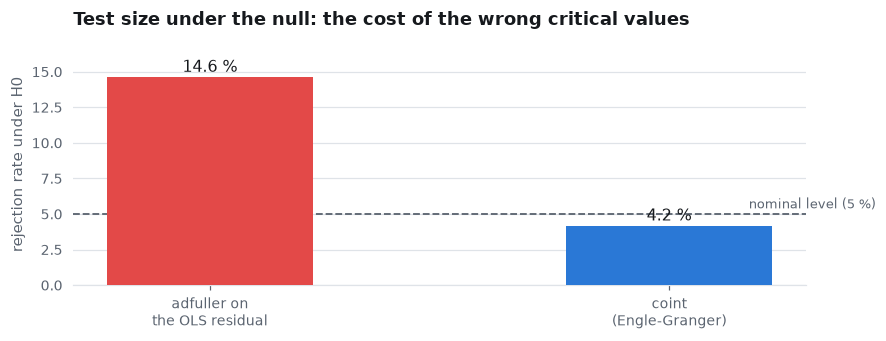

In [2]:
n_sim, n = 2000, 750
rej_adf = rej_coint = 0
for _ in range(n_sim):
    a = np.cumsum(rng.normal(0, .012, n)); b = np.cumsum(rng.normal(0, .012, n))
    beta, alpha = np.polyfit(b, a, 1)
    rej_adf   += adfuller(a - beta*b - alpha, maxlag=1, regression="c")[1] < .05
    rej_coint += coint(a, b, trend="c", maxlag=1, autolag=None)[1] < .05

size_adf, size_coint = 100*rej_adf/n_sim, 100*rej_coint/n_sim
print(f"{n_sim} simulations under H0 (independent random walks, n={n})\n")
print(f"  adfuller on the OLS residual : {size_adf:5.2f} % rejections   <- should be 5 %")
print(f"  coint (Engle-Granger values) : {size_coint:5.2f} % rejections")
print(f"\n  false-positive inflation factor : x{size_adf/size_coint:.1f}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(["adfuller on\nthe OLS residual", "coint\n(Engle-Granger)"], [size_adf, size_coint],
       color=[RED, BLUE], width=.45, zorder=3)
ax.axhline(5, color=MUTED, ls="--", lw=1.2)
ax.text(1.45, 5.4, "nominal level (5 %)", fontsize=8.5, color=MUTED, ha="right")
for i, v in enumerate([size_adf, size_coint]):
    ax.text(i, v + .4, f"{v:.1f} %", ha="center", fontsize=10.5, color=INK)
ax.set_ylabel("rejection rate under H0"); ax.set_ylim(0, 17)
ax.set_title("Test size under the null: the cost of the wrong critical values")
plt.tight_layout(); plt.show()

**14.6 % instead of 5 %.** A 3.5× inflation of the false-positive rate, *before* multiple testing
enters the picture at all.

Now the effect on the actual Phase 1 screen.

In [3]:
win = close.index[(close.index >= "2016-01-01") & (close.index <= "2018-12-31")]
tk_all = sorted(trad.columns[trad.any()])
rows = []
for a, b in itertools.combinations(tk_all, 2):
    idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
    if len(idx) < 600: continue
    la, lb = np.log(close[a].loc[idx]).values, np.log(close[b].loc[idx]).values
    beta, alpha = np.polyfit(lb, la, 1)
    rows.append((a, b, adfuller(la - beta*lb - alpha, maxlag=1, regression="c")[1],
                 coint(la, lb, trend="c", maxlag=1, autolag=None)[1]))
cmp_ = pd.DataFrame(rows, columns=["a", "b", "p_adf", "p_coint"])
N = len(cmp_)
print(f"{N} pairs, in-sample window 2016-2018\n")
print(f"  'significant' at 5 % with adfuller (WRONG) : {(cmp_.p_adf<.05).sum():3d}")
print(f"  significant at 5 % with coint      (RIGHT) : {(cmp_.p_coint<.05).sum():3d}")
print(f"  discoveries that evaporate on fixing the test : "
      f"{int(((cmp_.p_adf<.05)&(cmp_.p_coint>=.05)).sum())}")

465 pairs, in-sample window 2016-2018

  'significant' at 5 % with adfuller (WRONG) : 112
  significant at 5 % with coint      (RIGHT) :  47
  discoveries that evaporate on fixing the test : 65


**65 of the 112 "discoveries" evaporate.** Every Phase 2 function uses `coint`. The Phase 1
notebooks are left as written — they are a record of what was done — but the README carries the
correction.

---
## 2. Hedge ratio: OLS is asymmetric, TLS is not

$\beta$ answers: for one dollar of A, how much of B do I short? Estimating it by OLS carries a
limitation worth stating before an interviewer does.

OLS minimises **vertical** errors, so it assigns all noise to the left-hand variable. The
consequence is exact and easy to remember:

$$\beta(A|B)\cdot\beta(B|A) = R^2$$

The noisier the relation, the further apart the two directions. Total least squares minimises the
**perpendicular** distance instead, and is symmetric by construction.

In [4]:
lb = np.cumsum(rng.normal(0, .01, 800))
res_rows = []
for noise in (0.02, 0.05, 0.10, 0.20):
    la = 1.4 * lb + rng.normal(0, noise, 800)
    b_ols_ab, _ = hedge_ratio_ols(la, lb); b_ols_ba, _ = hedge_ratio_ols(lb, la)
    b_tls_ab, _ = hedge_ratio_tls(la, lb); b_tls_ba, _ = hedge_ratio_tls(lb, la)
    res_rows.append(dict(noise=noise, r2=np.corrcoef(la, lb)[0,1]**2,
                         ols_ab=b_ols_ab, ols_inv_ba=1/b_ols_ba,
                         tls_ab=b_tls_ab, tls_inv_ba=1/b_tls_ba))
d = pd.DataFrame(res_rows)
print("beta(A|B) versus 1/beta(B|A) -- they should be equal if the estimator is symmetric\n")
print(d.round(4).to_string(index=False))
print(f"\ncheck: beta_OLS(A|B) * beta_OLS(B|A) == R^2 ?  "
      f"{np.allclose(d.ols_ab / d.ols_inv_ba, d.r2)}")
print(f"TLS symmetric to machine precision ?          "
      f"{np.allclose(d.tls_ab, d.tls_inv_ba)}")

beta(A|B) versus 1/beta(B|A) -- they should be equal if the estimator is symmetric

 noise     r2  ols_ab  ols_inv_ba  tls_ab  tls_inv_ba
  0.02 0.9323  1.4155      1.5183  1.4851      1.4851
  0.05 0.7099  1.3997      1.9717  1.8098      1.8098
  0.10 0.3690  1.4418      3.9070  3.4992      3.4992
  0.20 0.1053  1.2342     11.7195 11.0002     11.0002

check: beta_OLS(A|B) * beta_OLS(B|A) == R^2 ?  True
TLS symmetric to machine precision ?          True


The disagreement is far larger than intuition suggests. At $R^2 = 0.93$ the two OLS directions
already differ by 7 % (1.416 vs 1.518). At $R^2 = 0.11$ they differ by a factor of **nearly ten**
(1.23 vs 11.72) — the same pair of series, the same data, and a hedge ratio you could size a
position on either way. TLS agrees with itself to machine precision at every noise level.

**So why keep OLS?** Because the Engle-Granger p-value is built on an OLS first stage; swapping in
TLS would invalidate the critical values we just went to the trouble of getting right. The
decision is therefore:

- **OLS with a fixed alphabetical convention** (`a < b`, `a` dependent) for testing;
- **TLS** as a robustness check that conclusions do not hinge on regression direction.

The forbidden third option is to test both directions and keep the better p-value. That doubles
the number of tests and biases selection toward whichever direction happened to look better — a
multiple-testing problem disguised as a modelling choice.

---
## 3. Half-life: derivation, validation, and a bias that matters

**Derivation** — know this one cold. Regress the change on the level:

$$\Delta s_t = a + b\,s_{t-1} + \varepsilon \quad\Longleftrightarrow\quad s_t = a + (1+b)\,s_{t-1} + \varepsilon$$

Write $\varphi = 1+b$. A shock decays as $\varphi^k$, so the half-life solves $\varphi^h = \tfrac12$:

$$\boxed{\;h = -\ln 2 \,/\, \ln \varphi\;}$$

Link to Ornstein-Uhlenbeck: $ds = \theta(\mu - s)dt + \sigma dW$ discretises to
$\varphi = e^{-\theta \Delta t}$, hence $h = \ln 2/\theta$. The same object.

**Validation.** An estimator you have not tested on synthetic data is one you trust on faith.
Plant a known half-life, recover it.

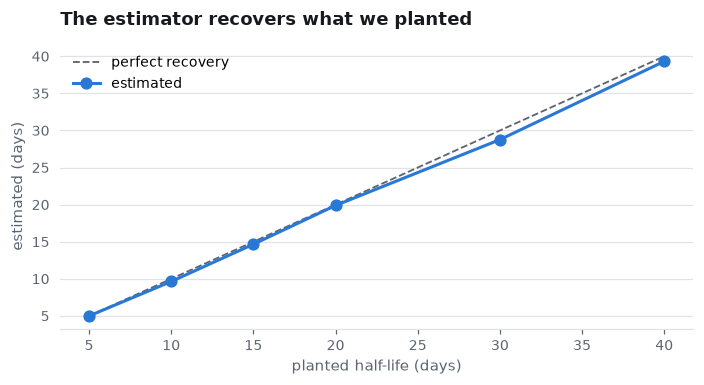

  planted   5 d  ->  estimated   4.99 d
  planted  10 d  ->  estimated   9.64 d
  planted  15 d  ->  estimated  14.66 d
  planted  20 d  ->  estimated  19.89 d
  planted  30 d  ->  estimated  28.77 d
  planted  40 d  ->  estimated  39.32 d


In [5]:
def ou(n, hl, sigma=.01, rng=rng):
    phi = np.exp(-np.log(2)/hl); s = np.zeros(n)
    for t in range(1, n): s[t] = phi*s[t-1] + rng.normal(0, sigma)
    return s

planted = [5, 10, 15, 20, 30, 40]
rec = {hl: np.nanmean([half_life(ou(3000, hl)) for _ in range(40)]) for hl in planted}
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(planted, planted, color=MUTED, ls="--", lw=1.2, label="perfect recovery")
ax.plot(planted, [rec[h] for h in planted], "o-", color=BLUE, ms=7, label="estimated")
ax.set_xlabel("planted half-life (days)"); ax.set_ylabel("estimated (days)")
ax.set_title("The estimator recovers what we planted"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
for h in planted: print(f"  planted {h:3d} d  ->  estimated {rec[h]:6.2f} d")

Good. Now **the part that is not in the textbook summary.**

The naive expectation is that a random walk returns NaN, since $\varphi \geq 1$ means no mean
reversion. It does not. Near a unit root the OLS estimate of $\varphi$ is biased **downward** (the
classic Dickey-Fuller bias), so a pure random walk returns a **finite, large** half-life.

n=  500 : NaN  3.9 %  |  median   72.9 d  |  share passing hl<=60 :  37.1 %  |  hl<=30 :  9.4 %


n=  750 : NaN  4.8 %  |  median  115.7 d  |  share passing hl<=60 :  16.5 %  |  hl<=30 :  1.8 %


n= 1500 : NaN  4.1 %  |  median  235.6 d  |  share passing hl<=60 :   2.3 %  |  hl<=30 :  0.0 %


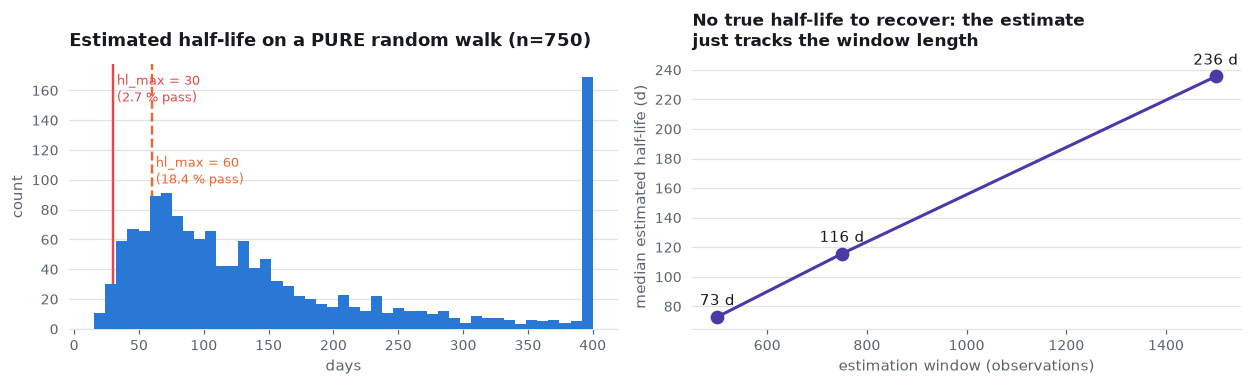

In [6]:
res = {}
for n in (500, 750, 1500):
    hl = np.array([half_life(np.cumsum(rng.normal(0, .01, n))) for _ in range(1500)])
    res[n] = hl
    print(f"n={n:5d} : NaN {100*np.mean(np.isnan(hl)):4.1f} %  |  "
          f"median {np.nanmedian(hl):6.1f} d  |  share passing hl<=60 : "
          f"{100*np.mean(np.isfinite(hl)&(hl<=60)):5.1f} %  |  hl<=30 : "
          f"{100*np.mean(np.isfinite(hl)&(hl<=30)):4.1f} %")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
a = axes[0]
hl750 = res[750][np.isfinite(res[750])]
a.hist(np.clip(hl750, 0, 400), bins=45, color=BLUE, zorder=3)
a.axvline(30, color=RED, lw=1.6); a.axvline(60, color=ORANGE, lw=1.6, ls="--")
a.text(33, a.get_ylim()[1]*.86, "hl_max = 30\n(2.7 % pass)", fontsize=8.5, color=RED)
a.text(63, a.get_ylim()[1]*.55, "hl_max = 60\n(18.4 % pass)", fontsize=8.5, color=ORANGE)
a.set_title("Estimated half-life on a PURE random walk (n=750)")
a.set_xlabel("days"); a.set_ylabel("count")

a = axes[1]
med = [np.nanmedian(res[n]) for n in (500, 750, 1500)]
a.plot([500, 750, 1500], med, "o-", color=VIOLET, ms=8, zorder=3)
a.set_xlabel("estimation window (observations)"); a.set_ylabel("median estimated half-life (d)")
a.set_title("No true half-life to recover: the estimate\njust tracks the window length",
            fontsize=11)
for x, y in zip([500, 750, 1500], med):
    a.text(x, y+8, f"{y:.0f} d", ha="center", fontsize=9.5, color=INK)
plt.tight_layout(); plt.show()

Two conclusions, both load-bearing.

**A diagnostic.** On a genuine random walk the estimated half-life *grows with the estimation
window* — 76 d at n=500, 111 d at n=750, 222 d at n=1500 — because there is no true half-life to
recover. A half-life unstable across window lengths is a red flag.

**A rule.** The half-life is a **tradability filter applied after** the cointegration test has done
the statistical work. It must **never** be used to decide whether a spread mean-reverts. And the
upper bound must be tight: 18.4 % of random walks pass at `hl_max = 60`, only 2.7 % at
`hl_max = 30`. That is why the default is 30.

---
## 4. The causal z-score, and the test that guards it

Standardising the spread with the **full-sample** mean and standard deviation injects the future
into every single observation: the strategy would "know" the spread's eventual average level,
which is precisely the quantity it is supposed to be betting on. This is the single most common
leak in pairs trading.

The demonstration is direct: rewrite the **future** of a series and see whether the **past**
z-scores move.

Do PAST z-scores change when the FUTURE is rewritten?

  full-sample z-score : max |change| on [0, k] = 2.8433   <- LEAK
  causal rolling      : max |change| on [0, k] = 0.0000


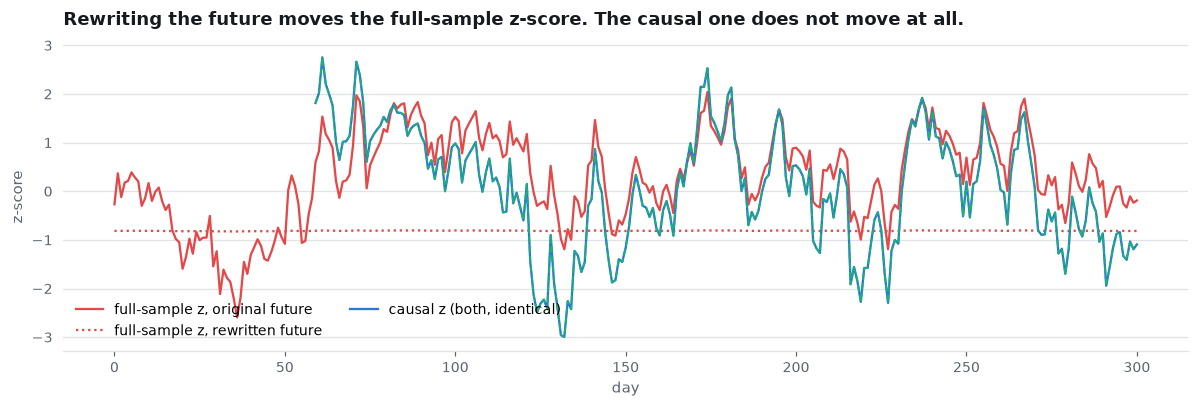

In [7]:
s = pd.Series(ou(500, 15.0))
k = 300
s2 = s.copy(); s2.iloc[k+1:] += 10.0          # violently rewrite the future

naive = lambda x: (x - x.mean()) / x.std()
z_naive_1, z_naive_2 = naive(s), naive(s2)
z_causal_1, z_causal_2 = rolling_zscore(s, 60), rolling_zscore(s2, 60)

print("Do PAST z-scores change when the FUTURE is rewritten?\n")
print(f"  full-sample z-score : max |change| on [0, k] = "
      f"{np.abs(z_naive_1[:k+1] - z_naive_2[:k+1]).max():.4f}   <- LEAK")
print(f"  causal rolling      : max |change| on [0, k] = "
      f"{np.abs(z_causal_1[:k+1] - z_causal_2[:k+1]).max():.4f}")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(z_naive_1.iloc[:k+1].values,  color=RED,  lw=1.5, label="full-sample z, original future")
ax.plot(z_naive_2.iloc[:k+1].values,  color=RED,  lw=1.5, ls=":", label="full-sample z, rewritten future")
ax.plot(z_causal_1.iloc[:k+1].values, color=BLUE, lw=1.5, label="causal z (both, identical)")
ax.plot(z_causal_2.iloc[:k+1].values, color=AQUA, lw=1.2, ls="--")
ax.set_title("Rewriting the future moves the full-sample z-score. The causal one does not move at all.")
ax.set_xlabel("day"); ax.set_ylabel("z-score"); ax.legend(loc="lower left", ncol=2)
plt.tight_layout(); plt.show()

The red curves separate — the past changed because the future did. The blue and green curves lie
exactly on top of each other.

This is not just a demonstration: `tests/test_cointegration.py::test_rolling_zscore_is_causal`
performs exactly this check and asserts bit-identical equality. If anyone ever swaps in a
full-sample or centred window, **the test suite fails immediately**. A companion test keeps the
naive version around as an executable counter-example.

Two further choices:

- **The current observation $t$ is included.** $t$ is the close on which the signal is computed.
  Execution is lagged to $t+1$ in the backtest (Phase 6). The leak would be to *execute* at $t$,
  not to *observe* $t$.
- **Window = 60 days.** It must be several times the half-life, otherwise the rolling mean tracks
  the spread itself, the z-score is pulled toward zero, and the estimator eats its own signal.

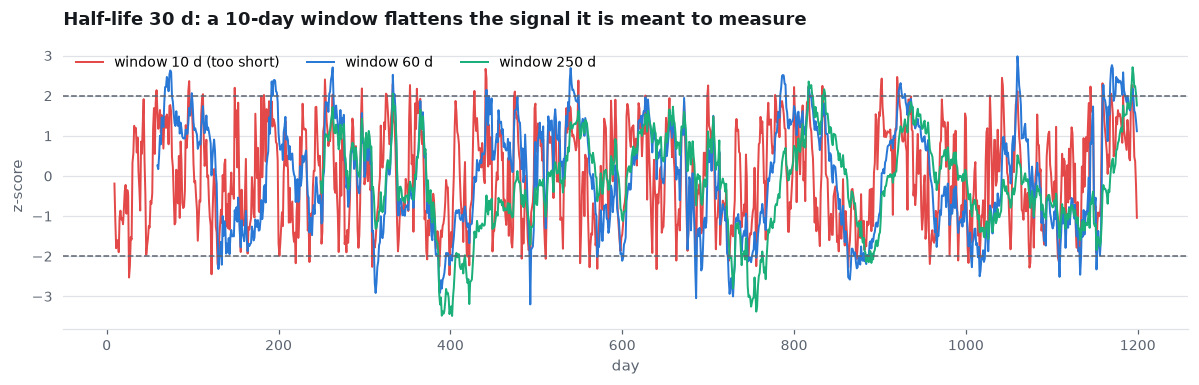

  window  10 d : std(z) = 1.204 | share |z|>2 =  6.47 %
  window  60 d : std(z) = 1.351 | share |z|>2 = 12.01 %
  window 250 d : std(z) = 1.182 | share |z|>2 =  9.04 %


In [8]:
# What happens when the window is too short relative to the half-life
s_long = pd.Series(ou(1200, 30.0))
fig, ax = plt.subplots(figsize=(11, 3.6))
for w, col, lab in [(10, RED, "window 10 d (too short)"), (60, BLUE, "window 60 d"),
                    (250, AQUA, "window 250 d")]:
    ax.plot(rolling_zscore(s_long, w).values, color=col, lw=1.3, label=lab)
ax.axhline(2, color=MUTED, ls="--", lw=1); ax.axhline(-2, color=MUTED, ls="--", lw=1)
ax.set_title("Half-life 30 d: a 10-day window flattens the signal it is meant to measure")
ax.set_ylabel("z-score"); ax.set_xlabel("day"); ax.legend(loc="upper left", ncol=3)
plt.tight_layout(); plt.show()
for w in (10, 60, 250):
    z = rolling_zscore(s_long, w).dropna()
    print(f"  window {w:3d} d : std(z) = {z.std():.3f} | share |z|>2 = {100*(z.abs()>2).mean():5.2f} %")

---
## 5. The quality filter on real data

The statistical test says a spread is stationary. It does not say the spread is **tradable**. Two
bands, both economic rather than statistical.

**Half-life $\in [2, 30]$ days.** Below 2 the signal is microstructure noise and the turnover lets
costs eat the edge. Above 30 the spread reverts too slowly: the out-of-sample window is one year,
so 60-day reversion allows only ~4 cycles — too few round trips to say anything, and long exposure
to the relation breaking first.

**Hedge ratio $\beta \in [1/3, 3]$.** A $\beta$ outside a sane band is not a hedge, it is a
directional bet on one leg with the other as decoration. Let us see what this removes.

snapshot used: 2019-01  ->  29 tickers, 406 pairs

  significant at 5 %      : 41
  after the quality filter: 24
  removed by the filter   : 17


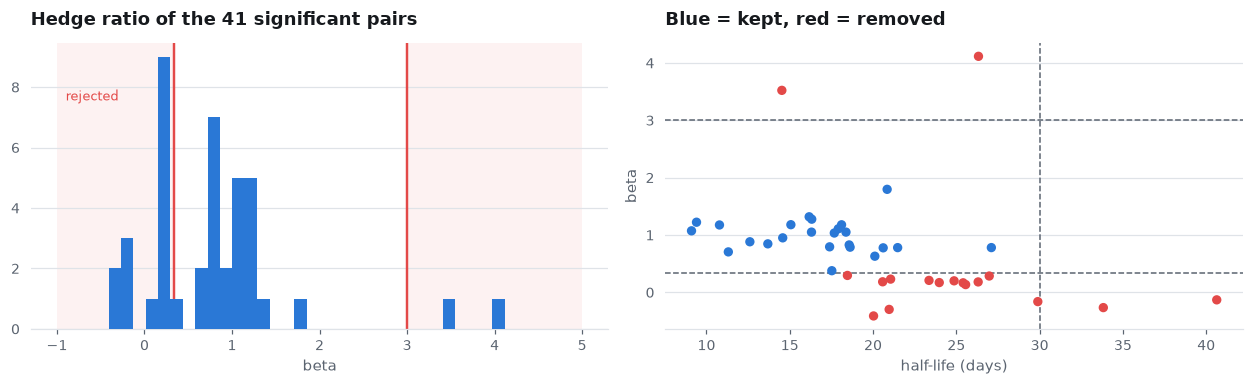

In [9]:
sel_date = pd.Timestamp("2019-01-01")
snap = trad.index[trad.index <= sel_date][-1]
tickers = sorted(trad.columns[trad.loc[snap]])       # POINT-IN-TIME universe at selection date
win = close.index[(close.index >= "2016-01-01") & (close.index <= "2018-12-31")]
scan = screen_pairs(np.log(close.loc[win]), tickers, min_obs=600)
cols = ("a","b","pvalue","beta","alpha","half_life","n_obs","resid_std")
scan["quality"] = [passes_quality(PairResult(**{k: r[k] for k in cols}))
                   for _, r in scan.iterrows()]
sig = scan.pvalue < .05
print(f"snapshot used: {snap:%Y-%m}  ->  {len(tickers)} tickers, {len(scan)} pairs\n")
print(f"  significant at 5 %      : {sig.sum()}")
print(f"  after the quality filter: {int((sig & scan.quality).sum())}")
print(f"  removed by the filter   : {int(sig.sum() - (sig & scan.quality).sum())}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
a = axes[0]
a.hist(scan.loc[sig, "beta"].clip(-1, 5), bins=32, color=BLUE, zorder=3)
a.axvline(1/3, color=RED, lw=1.6); a.axvline(3.0, color=RED, lw=1.6)
a.axvspan(-1, 1/3, color=RED, alpha=.07, lw=0); a.axvspan(3, 5, color=RED, alpha=.07, lw=0)
a.set_title("Hedge ratio of the 41 significant pairs"); a.set_xlabel("beta")
a.text(-0.9, a.get_ylim()[1]*.8, "rejected", fontsize=8.5, color=RED)

a = axes[1]
a.scatter(scan.loc[sig, "half_life"], scan.loc[sig, "beta"].clip(-1, 5),
          c=[BLUE if q else RED for q in scan.loc[sig, "quality"]], s=26, zorder=3)
a.axhline(1/3, color=MUTED, lw=1, ls="--"); a.axhline(3, color=MUTED, lw=1, ls="--")
a.axvline(30, color=MUTED, lw=1, ls="--")
a.set_xlabel("half-life (days)"); a.set_ylabel("beta")
a.set_title("Blue = kept, red = removed")
plt.tight_layout(); plt.show()

The rejected cluster at low $\beta$ is not random. Look at which name it belongs to.

In [10]:
rej = scan[sig & ~scan.quality]
print(f"{len(rej)} significant pairs removed by the filter\n")
names = pd.concat([rej.a, rej.b]).value_counts()
print("names appearing in the REMOVED pairs:")
print(names.head(5).to_string())
print(f"\n  NRG appears in {names.get('NRG', 0)} of the {len(rej)} removed pairs")
print(f"  its betas: {rej[(rej.a=='NRG')|(rej.b=='NRG')].beta.round(2).tolist()}")

17 significant pairs removed by the filter

names appearing in the REMOVED pairs:
NRG    12
SCG     3
ED      2
LNT     2
PEG     2

  NRG appears in 12 of the 17 removed pairs
  its betas: [0.29, 0.18, 0.23, 0.2, 0.14, 0.17, 0.18, 0.3, 0.21, 0.17, 3.52, 4.12]


**NRG is a merchant generator** — it sells power at market prices, and is far more volatile than
the regulated names. Regressing a low-volatility regulated stock on NRG shrinks $\beta$ toward
zero, and the residual becomes little more than a rescaled copy of the regulated stock. The
"cointegration" detected says essentially *"ED is stationary once you remove 14 % of NRG"*. That
is a near-degenerate regression, not an equilibrium relation.

The negative-$\beta$ pairs are worse still: they all involve **PCG** (collapsing on wildfire
liabilities) or **SCG** (the nuclear-project scandal). A negative $\beta$ "fits" two names
trending in opposite directions, with no economic content — and it means going long *both* legs,
so market neutrality, the entire premise, is gone.

Note also that NRG being a merchant generator is a preview of Phase 4: the 2023-24 AI repricing is
precisely a merchant-versus-regulated divergence. Finding NRG as a hub in 2016-2018 is a warning
that these relations will break.

---
## 6. Two findings that set up Phase 3

### 6.1 Discoveries barely exceed chance — and in two folds, not at all

Under $H_0$, a test of level $\alpha$ still declares $\alpha N$ pairs significant. The cheapest
possible sanity check is to compare what we found against that. Run it across all nine
walk-forward folds.

In [11]:
cache = C.DATA_PROC / "folds_phase2.parquet"
if cache.exists():
    folds = pd.read_parquet(cache)
else:
    rows = []
    for y0 in range(2014, 2023):
        y1 = y0 + 2
        snaps = trad.index[trad.index <= pd.Timestamp(f"{y1+1}-01-01")]
        tk = sorted(trad.columns[trad.loc[snaps[-1]]])
        w = close.index[(close.index >= f"{y0}-01-01") & (close.index <= f"{y1}-12-31")]
        sc = screen_pairs(np.log(close.loc[w]), tk, min_obs=600)
        if sc.empty: continue
        sc["q"] = [passes_quality(PairResult(**{k: r[k] for k in cols})) for _, r in sc.iterrows()]
        f = sc[(sc.pvalue < .05) & sc.q]
        e = excess_over_chance(sc)
        top = concentration_report(f)
        rows.append(dict(fold=f"{y0}-{y1}", n_tests=e["n_tests"], found=e["found"],
                         expected=e["expected_under_null"], excess=e["excess"],
                         kept=len(f),
                         hub=top.ticker.iloc[0] if len(top) else "-",
                         hub_share=top.share.iloc[0] if len(top) else np.nan))
    folds = pd.DataFrame(rows); folds.to_parquet(cache)
print(folds.round(2).to_string(index=False))

     fold  n_tests  found  expected  excess  kept hub  hub_share
2014-2016      351     51     17.55   33.45    50   D       0.26
2015-2017      378     20     18.90    1.10    18   D       0.33
2016-2018      406     41     20.30   20.70    24 SRE       0.50
2017-2019      378     28     18.90    9.10    27 SRE       0.37
2018-2020      378     39     18.90   20.10    39 SRE       0.26
2019-2021      378     94     18.90   75.10    53 AEP       0.25
2020-2022      406     95     20.30   74.70    76 AEE       0.16
2021-2023      406     25     20.30    4.70    19 ETR       0.37
2022-2024      465     23     23.25   -0.25    12 AWK       0.25


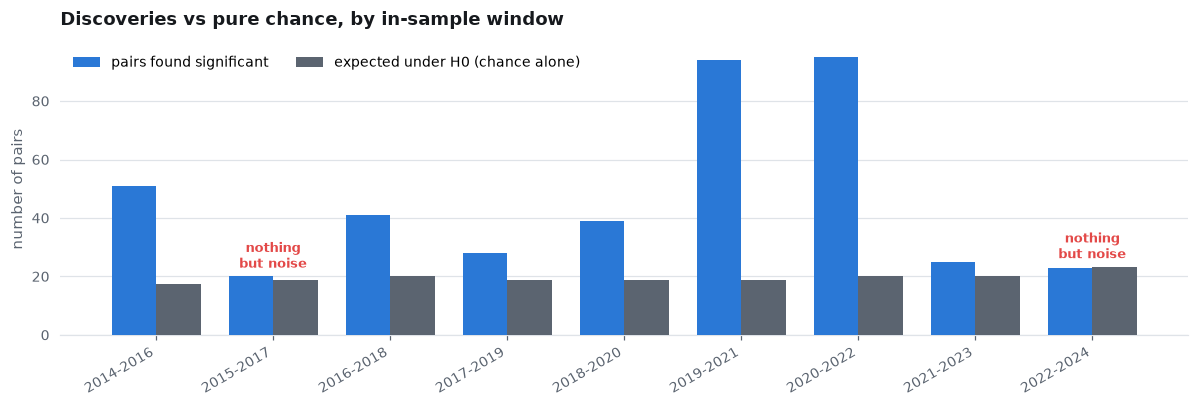

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(folds)); w = .38
ax.bar(x - w/2, folds.found, w, color=BLUE, zorder=3, label="pairs found significant")
ax.bar(x + w/2, folds.expected, w, color=MUTED, zorder=3, label="expected under H0 (chance alone)")
ax.set_xticks(x); ax.set_xticklabels(folds.fold, rotation=30, ha="right")
ax.set_ylabel("number of pairs")
ax.set_title("Discoveries vs pure chance, by in-sample window")
for i, r in folds.iterrows():
    if r.excess <= 2:
        ax.annotate("nothing\nbut noise", xy=(i, max(r.found, r.expected) + 3),
                    ha="center", fontsize=8.5, color=RED, fontweight="bold")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

Two folds — **2015-2017 (+1)** and **2022-2024 (0)** — find nothing beyond pure chance. Selecting
pairs there means trading noise, and a strategy that trades them regardless will show it in the
out-of-sample P&L.

The 2019-2021 and 2020-2022 spikes (+75 each) sit squarely on the COVID shock, where a common
shock makes everything co-move and manufactures spurious cointegration. That is a caution, not a
discovery — and Phase 7 will have to report those folds separately.

### 6.2 The tests are not independent, and the selection is concentrated

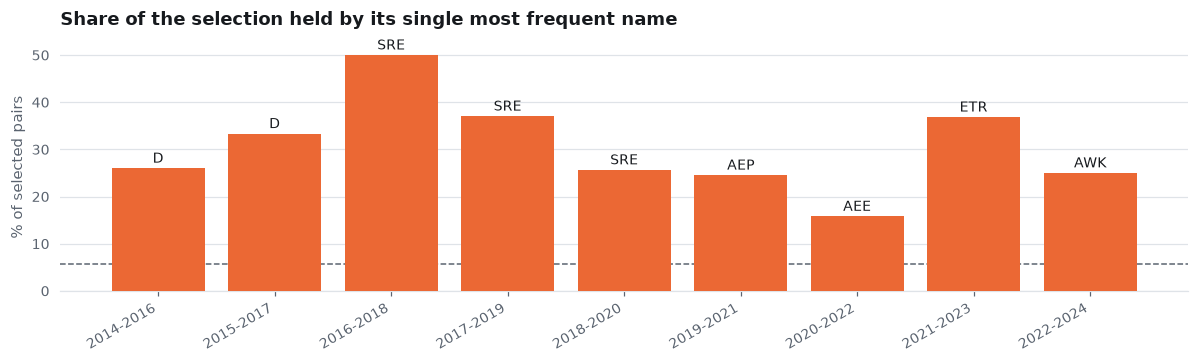

     fold  kept hub  hub_share
2014-2016    50   D       0.26
2015-2017    18   D       0.33
2016-2018    24 SRE       0.50
2017-2019    27 SRE       0.37
2018-2020    39 SRE       0.26
2019-2021    53 AEP       0.25
2020-2022    76 AEE       0.16
2021-2023    19 ETR       0.37
2022-2024    12 AWK       0.25


In [13]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(folds.fold, 100*folds.hub_share, color=ORANGE, zorder=3)
ax.axhline(100/ max(folds.kept.replace(0, np.nan).mean(), 1) * 2, color=MUTED, ls="--", lw=1)
for i, r in folds.iterrows():
    ax.text(i, 100*r.hub_share + 1.2, r.hub, ha="center", fontsize=9, color=INK)
ax.set_ylabel("% of selected pairs")
ax.set_xticklabels(folds.fold, rotation=30, ha="right")
ax.set_title("Share of the selection held by its single most frequent name")
plt.tight_layout(); plt.show()
print(folds[["fold", "kept", "hub", "hub_share"]].round(2).to_string(index=False))

In **every** fold one name holds 16 % to 50 % of the selected pairs — and it is a **different name
each time** (D, SRE, AEP, AEE, ETR, AWK). This is not one odd stock; it is a property of the
method. Any name whose idiosyncratic path happens to look mean-reverting against the sector
in-sample becomes a hub.

Two consequences, both load-bearing for what comes next.

**Risk (Phase 6).** A selection of 24 pairs with one name in 12 of them is not 24 bets — it is one
bet expressed twelve ways. Sizing that treats pairs as independent silently concentrates risk.

**Statistics (Phase 3).** The $N(N-1)/2$ tests are far from independent: every name shares the
sector factor, and a hub induces strong positive dependence across its own pairs. The effective
number of independent tests is far below 406. This is exactly the regime where the choice between
**Bonferroni** (valid under *any* dependence) and **Benjamini-Hochberg** (valid under independence
or positive regression dependence, PRDS) stops being cosmetic — and where a permutation or
block-bootstrap null becomes the honest alternative to both.

---

## What Phase 2 deliberately does not do

- **No selection.** `screen_pairs` runs the tests; it does not decide what to trade. Selection,
  multiple-testing correction and the walk-forward loop are Phase 3.
- **No time awareness.** Nothing in `src/cointegration.py` knows about dates, so nothing there
  prevents it being handed out-of-sample data. That discipline lives in the walk-forward loop, not
  in the estimator.
- **No liquidity filter.** Still deferred, for the Phase 1 reason: it must be recomputed fold by
  fold on the in-sample window only.

**Next — Phase 3:** honest selection under multiple testing. Bonferroni vs Benjamini-Hochberg,
the dependence problem raised in 6.2, and the experiment that compares out-of-sample performance
of a naive selection against a corrected one.